In [1]:
import ast
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.dummy import DummyClassifier
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [2]:
processed_dir = Path("../data/processed")
figures_dir = Path("../figures")
results_dir = Path("../results")
models_dir = Path("../models")

figures_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)


In [3]:
heart_final = pd.read_csv(processed_dir / "heart_final.csv")

train_data = heart_final[heart_final["split"] == "train"].copy()
test_data = heart_final[heart_final["split"] == "test"].copy()

X_train = train_data.drop(columns=["target", "split"])
y_train = train_data["target"]
X_test = test_data.drop(columns=["target", "split"])
y_test = test_data["target"]

X_train.shape, X_test.shape


((736, 27), (184, 27))

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model(model, X_train_data, y_train_data, X_test_data, y_test_data, model_name):
    cv_scores = cross_val_score(model, X_train_data, y_train_data, cv=cv, scoring="accuracy")
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_data)[:, 1]
    else:
        y_score = model.decision_function(X_test_data)

    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test_data, y_pred),
        "precision": precision_score(y_test_data, y_pred, zero_division=0),
        "recall": recall_score(y_test_data, y_pred, zero_division=0),
        "f1": f1_score(y_test_data, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test_data, y_score),
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std()
    }


In [5]:
knn_metrics = pd.read_csv(results_dir / "knn_metrics.csv")
decision_tree_metrics = pd.read_csv(results_dir / "decision_tree_metrics.csv")
random_forest_metrics = pd.read_csv(results_dir / "random_forest_metrics.csv")

best_k = int(knn_metrics.loc[0, "best_k"])
best_depth = int(decision_tree_metrics.loc[0, "best_max_depth"])
best_rf_params = ast.literal_eval(random_forest_metrics.loc[0, "best_params"])


In [6]:
models = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=best_depth, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(**best_rf_params, class_weight="balanced", random_state=42)
}


In [7]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_result = evaluate_model(baseline_model, X_train, y_train, X_test, y_test, "Dummy Baseline")
baseline_metrics = pd.DataFrame([baseline_result])
baseline_metrics


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Dummy Baseline,0.554348,0.554348,1.0,0.713287,0.5,0.552988,0.002688


In [8]:
final_model_comparison = pd.read_csv(results_dir / "final_model_comparison.csv")
baseline_comparison = pd.concat([baseline_metrics, final_model_comparison], ignore_index=True)
baseline_comparison = baseline_comparison[["model", "accuracy", "precision", "recall", "f1", "roc_auc", "cv_mean", "cv_std"]]
baseline_comparison


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Dummy Baseline,0.554348,0.554348,1.000000,0.713287,0.500000,0.552988,0.002688
1,Logistic Regression,0.831522,0.851485,0.843137,0.847291,0.913439,0.827413,0.034718
2,Random Forest,0.809783,0.831683,0.823529,0.827586,0.904830,0.832901,0.036042
3,KNN,0.847826,0.842593,0.892157,0.866667,0.902080,0.850561,0.028110
4,Decision Tree,0.760870,0.773585,0.803922,0.788462,0.755619,0.759542,0.020936


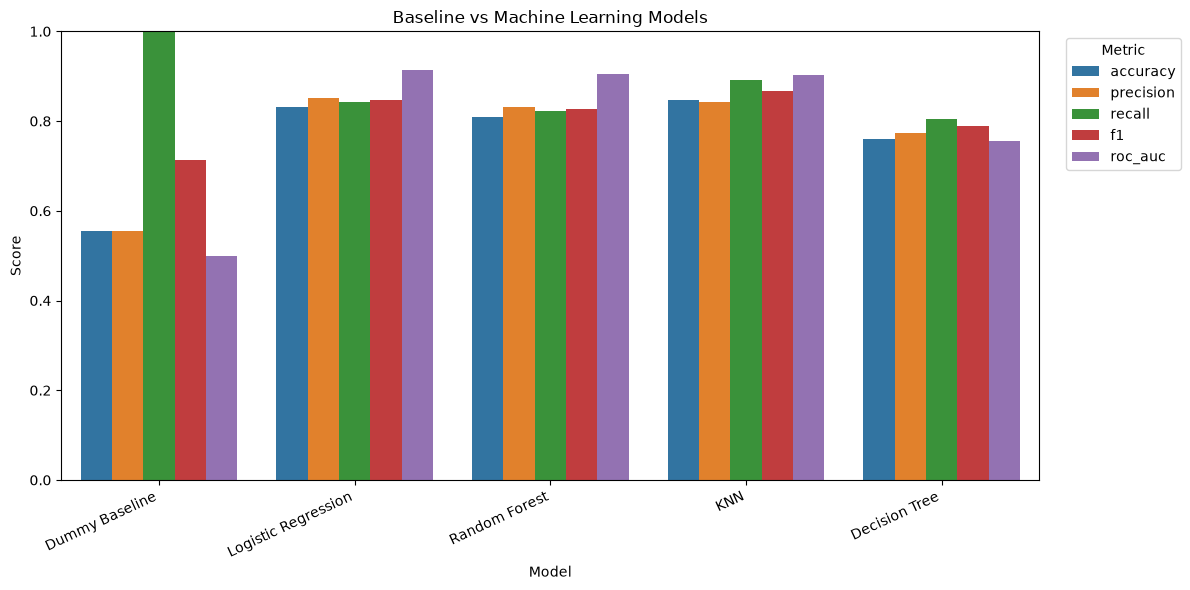

In [9]:
baseline_plot_data = baseline_comparison.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=baseline_plot_data, x="model", y="score", hue="metric")
plt.title("Baseline vs Machine Learning Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(figures_dir / "baseline_comparison.png", dpi=300)
plt.show()


In [10]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train)

explained_variance = pd.DataFrame({
    "component": np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
    "explained_variance_ratio": pca_full.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_full.explained_variance_ratio_)
})

explained_variance.head()


,component,explained_variance_ratio,cumulative_variance
0,1,0.216086,0.216086
1,2,0.148233,0.364319
2,3,0.106807,0.471126
3,4,0.095315,0.566441
4,5,0.085005,0.651446


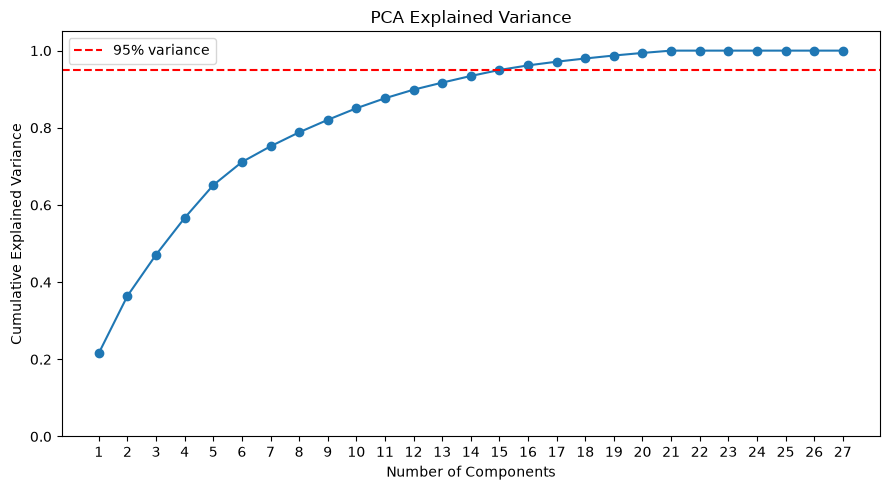

In [11]:
plt.figure(figsize=(9, 5))
plt.plot(explained_variance["component"], explained_variance["cumulative_variance"], marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance")
plt.title("PCA Explained Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.xticks(explained_variance["component"])
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.savefig(figures_dir / "pca_explained_variance.png", dpi=300)
plt.show()


In [12]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

pca_feature_names = [f"PC{i}" for i in range(1, X_train_pca.shape[1] + 1)]
X_train_pca = pd.DataFrame(X_train_pca, columns=pca_feature_names)
X_test_pca = pd.DataFrame(X_test_pca, columns=pca_feature_names)

X_train_pca.shape, X_test_pca.shape


((736, 16), (184, 16))

In [13]:
pca_results = []

for model_name, model in models.items():
    pca_results.append(evaluate_model(model, X_train_pca, y_train, X_test_pca, y_test, model_name))

pca_model_comparison = pd.DataFrame(pca_results)
pca_model_comparison = pca_model_comparison.sort_values(["roc_auc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
pca_model_comparison


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,KNN,0.842391,0.834862,0.892157,0.862559,0.911824,0.827413,0.021561
1,Logistic Regression,0.826087,0.843137,0.843137,0.843137,0.898015,0.813881,0.032222
2,Random Forest,0.831522,0.831776,0.872549,0.851675,0.894070,0.831495,0.024272
3,Decision Tree,0.766304,0.792079,0.784314,0.788177,0.764108,0.751361,0.019492


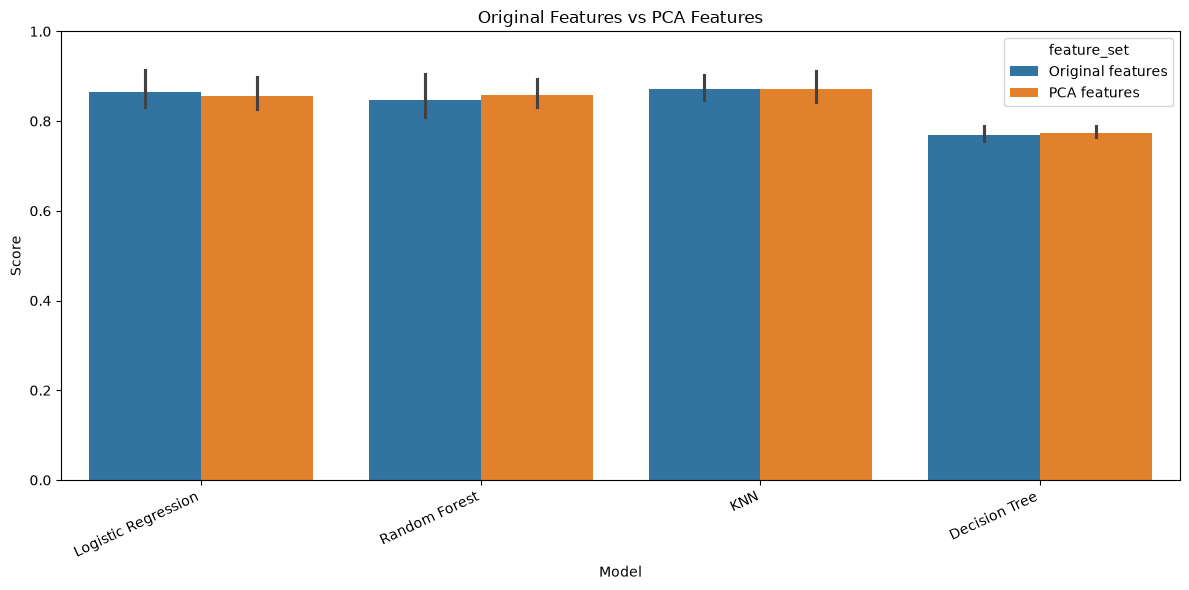

In [14]:
original_vs_pca = final_model_comparison.copy()
original_vs_pca["feature_set"] = "Original features"
pca_display = pca_model_comparison.copy()
pca_display["feature_set"] = "PCA features"

original_vs_pca = pd.concat([original_vs_pca, pca_display], ignore_index=True)
original_vs_pca_plot = original_vs_pca.melt(
    id_vars=["model", "feature_set"],
    value_vars=["accuracy", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=original_vs_pca_plot, x="model", y="score", hue="feature_set")
plt.title("Original Features vs PCA Features")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "pca_model_comparison.png", dpi=300)
plt.show()


In [15]:
best_original = final_model_comparison.sort_values(["roc_auc", "f1", "accuracy"], ascending=False).iloc[0]
best_pca = pca_model_comparison.sort_values(["roc_auc", "f1", "accuracy"], ascending=False).iloc[0]

if best_pca["roc_auc"] > best_original["roc_auc"]:
    pca_decision = "PCA improved the best ROC-AUC score, so it can be considered useful for this dataset."
else:
    pca_decision = "PCA did not improve the best ROC-AUC score, so the original processed features remain better for final modeling."

pca_decision


'PCA did not improve the best ROC-AUC score, so the original processed features remain better for final modeling.'

In [16]:
dataset_columns = [column for column in X_train.columns if column.startswith("dataset_")]
X_train_no_dataset = X_train.drop(columns=dataset_columns)
X_test_no_dataset = X_test.drop(columns=dataset_columns)

dataset_columns


['dataset_cleveland',
 'dataset_hungary',
 'dataset_switzerland',
 'dataset_va long beach']

In [17]:
no_dataset_results = []

for model_name, model in models.items():
    no_dataset_results.append(evaluate_model(model, X_train_no_dataset, y_train, X_test_no_dataset, y_test, model_name))

no_dataset_comparison = pd.DataFrame(no_dataset_results)
no_dataset_comparison = no_dataset_comparison.sort_values(["roc_auc", "f1", "accuracy"], ascending=False).reset_index(drop=True)
no_dataset_comparison


,model,accuracy,precision,recall,f1,roc_auc,cv_mean,cv_std
0,Random Forest,0.826087,0.824074,0.872549,0.847619,0.892874,0.831541,0.028865
1,Logistic Regression,0.815217,0.826923,0.843137,0.834951,0.892516,0.804376,0.042314
2,KNN,0.820652,0.805310,0.892157,0.846512,0.876674,0.832883,0.023385
3,Decision Tree,0.760870,0.773585,0.803922,0.788462,0.755619,0.759542,0.020936


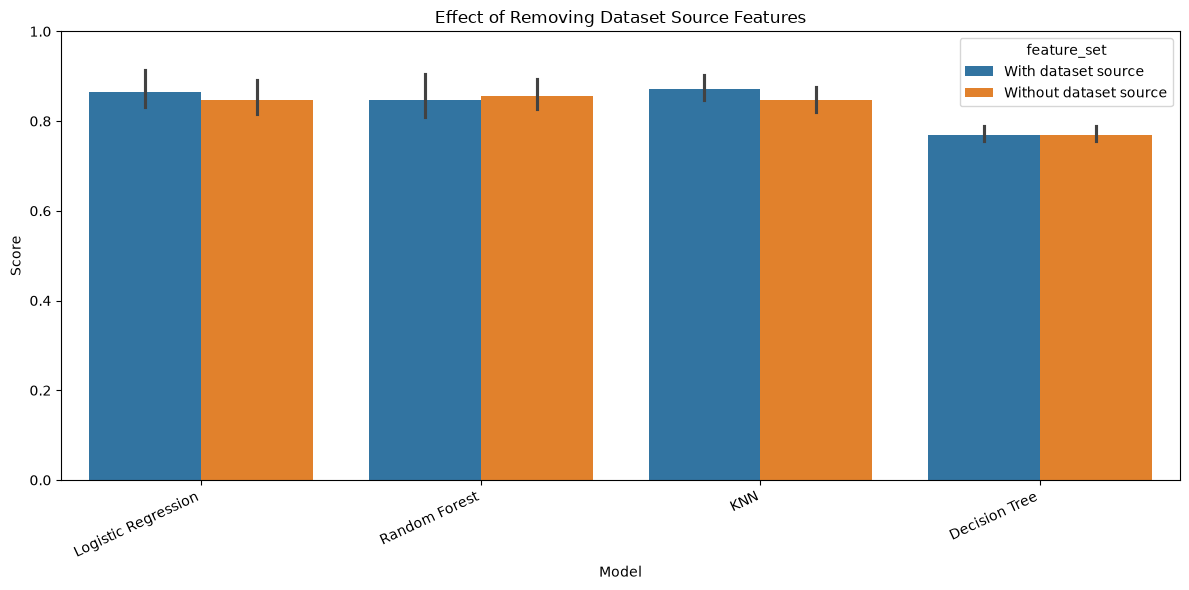

In [18]:
dataset_check = final_model_comparison.copy()
dataset_check["feature_set"] = "With dataset source"
no_dataset_display = no_dataset_comparison.copy()
no_dataset_display["feature_set"] = "Without dataset source"

dataset_check = pd.concat([dataset_check, no_dataset_display], ignore_index=True)
dataset_check_plot = dataset_check.melt(
    id_vars=["model", "feature_set"],
    value_vars=["accuracy", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=dataset_check_plot, x="model", y="score", hue="feature_set")
plt.title("Effect of Removing Dataset Source Features")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(figures_dir / "dataset_source_experiment_comparison.png", dpi=300)
plt.show()


In [19]:
baseline_metrics.to_csv(results_dir / "baseline_metrics.csv", index=False)
baseline_comparison.to_csv(results_dir / "baseline_comparison.csv", index=False)
explained_variance.to_csv(results_dir / "pca_explained_variance.csv", index=False)
pca_model_comparison.to_csv(results_dir / "pca_model_comparison.csv", index=False)
original_vs_pca.to_csv(results_dir / "original_vs_pca_comparison.csv", index=False)
no_dataset_comparison.to_csv(results_dir / "no_dataset_source_model_comparison.csv", index=False)
